In [2]:
import os
import pandas as pd
from datetime import datetime, timedelta
from eo_tides.model import model_phases
from eo_tides.utils import clip_models
from eo_tides.utils import list_models

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm

In [2]:
# # Clip tidal models to Cape Cod bounding box
# available_models, supported_models = list_models(
#     directory="tide_models/"
# )
# # Define bounding Box
# bbox_capecod = [-70.451122, 41.172320, -69.578025, 42.198560]
# clip_models(input_directory = "tide_models/",
#             output_directory = "tide_models_clipped",
#             model = "DTU23",
#             bbox = bbox_capecod)

In [3]:
# Get tide height data for Marconi Beach
start = "2026-07-15 00:00:00"
end = "2026-12-31 23:59:00"
tide_df= model_phases(
        x=-69.963189,
        y=41.896050, 
        time=pd.date_range(start, end, freq="10min"),
        model = "FES2022_extrapolated",
        #model=["EOT20", "GOT5.5","GOT5.6","FES2022_extrapolated"],
        output_format = "wide",
        directory="tide_models_clipped/",
        return_tides = True,
)


Modelling tides with FES2022_extrapolated
Modelling tides with FES2022_extrapolated
Converting to a wide format dataframe


In [5]:
tide_df["time"] = pd.date_range(start=start, end=pd.to_datetime(end),freq=timedelta(minutes=10))
col = tide_df.pop("time")
tide_df.insert(0, "time", col)
tide_df = tide_df.iloc[1:]
colhead = ["time","FES2022_heightm","FES2022_stage"]
#colhead = ["time",'EOT20_heightm',"GOT5.5_heightm","GOT5.6_heightm","FES2022_heightm","EOT20_stage","GOT5.5_stage","GOT5.6_stage","FES2022_stage"]
tide_df.columns=colhead
print(tide_df)
startstr = pd.to_datetime(start).strftime('%Y%m%d')
endstr = pd.to_datetime(end).strftime('%Y%m%d')
tide_df.to_csv(f"tidal_data_marconi_modelled_{startstr}-{endstr}.csv", index=False)


                                                       time  FES2022_heightm  \
time                x          y                                               
2026-07-15 00:10:00 -69.963189 41.89605 2026-07-15 00:10:00        -0.328231   
2026-07-15 00:20:00 -69.963189 41.89605 2026-07-15 00:20:00        -0.224981   
2026-07-15 00:30:00 -69.963189 41.89605 2026-07-15 00:30:00        -0.118973   
2026-07-15 00:40:00 -69.963189 41.89605 2026-07-15 00:40:00        -0.010895   
2026-07-15 00:50:00 -69.963189 41.89605 2026-07-15 00:50:00         0.098560   
...                                                     ...              ...   
2026-12-31 23:10:00 -69.963189 41.89605 2026-12-31 23:10:00         0.880111   
2026-12-31 23:20:00 -69.963189 41.89605 2026-12-31 23:20:00         0.859017   
2026-12-31 23:30:00 -69.963189 41.89605 2026-12-31 23:30:00         0.831556   
2026-12-31 23:40:00 -69.963189 41.89605 2026-12-31 23:40:00         0.797893   
2026-12-31 23:50:00 -69.963189 41.89605 

                                                       time  FES2022_heightm  \
time                x          y                                               
2026-07-15 00:10:00 -69.963189 41.89605 2026-07-15 00:10:00        -0.328231   
2026-07-15 00:20:00 -69.963189 41.89605 2026-07-15 00:20:00        -0.224981   
2026-07-15 00:30:00 -69.963189 41.89605 2026-07-15 00:30:00        -0.118973   
2026-07-15 00:40:00 -69.963189 41.89605 2026-07-15 00:40:00        -0.010895   
2026-07-15 00:50:00 -69.963189 41.89605 2026-07-15 00:50:00         0.098560   
...                                                     ...              ...   
2026-12-31 23:10:00 -69.963189 41.89605 2026-12-31 23:10:00         0.880111   
2026-12-31 23:20:00 -69.963189 41.89605 2026-12-31 23:20:00         0.859017   
2026-12-31 23:30:00 -69.963189 41.89605 2026-12-31 23:30:00         0.831556   
2026-12-31 23:40:00 -69.963189 41.89605 2026-12-31 23:40:00         0.797893   
2026-12-31 23:50:00 -69.963189 41.89605 

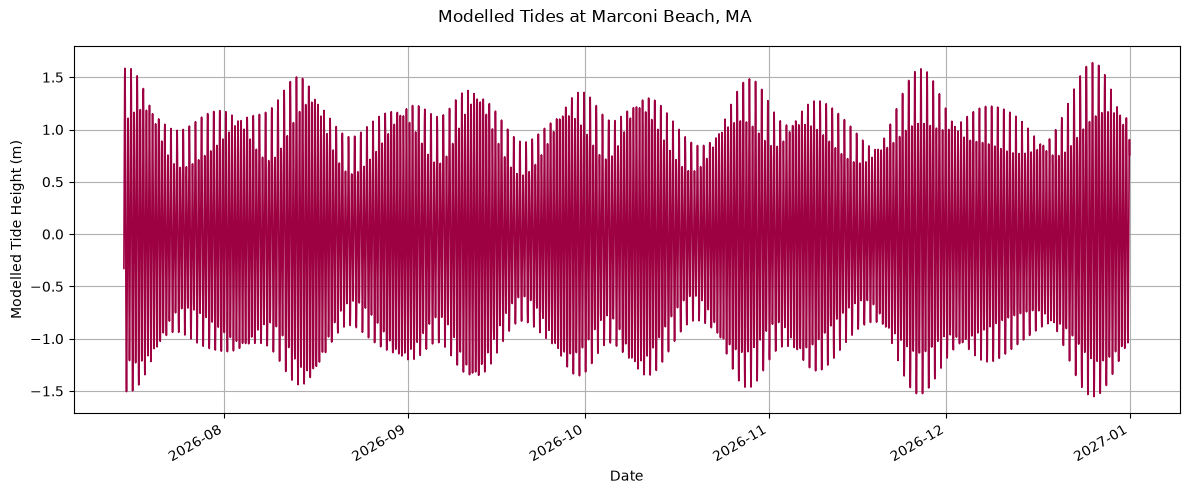

In [11]:

print(tide_df)
tide_columns= ["FES2022_heightm"] #,"EOT20","GOT5.5","GOT5.6"]
# Plotted FES2022b on each for comparison, couldn't find a better way to iterate the labels
#labels = ["FES2022b","FES2022b","EOT20","FES2022b","GOT5.5","FES2022b","GOT5.6","FES2022b"]
labels = ["FES2022b","FES2022b"]
cmap = plt.get_cmap('Spectral')
axes = tide_df.plot(figsize = (12, 5),
                    x = "time",
                    y = tide_columns,
                    title="Modelled Tides at Marconi Beach, MA",
                    ylabel="Modelled Tide Height (m)",
                    xlabel="Date",
                    subplots=True,
                    grid=True,
                    x_compat=True,
                    legend=False,
                    cmap = cmap,
                    linewidth = 1.2);

# # for i,ax in enumerate(axes):
# #     ax.plot(tide_df["time"], 
# #             tide_df["heightm"],
# #             color = "black",
# #             linewidth=4,
# #             alpha = 0.2,
# #             zorder = 3,
# #            )
# #     start_idx = i * 2
# #     end_idx = start_idx + 2
    
#     # Pass the list of strings to the legend
#     ax.legend(labels[start_idx:end_idx],loc='upper right')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()
